In [ ]:
import pandas as pd
import re
import openai
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import random
import tabulate
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, 
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
from tqdm.auto import tqdm
import joblib
from itertools import product
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Load dataset
df = pd.read_csv("Training/ranked_responses_final.csv")

In [3]:
# Later, when you want to load the embeddings without recomputing:
with open("df_processed.pkl", "rb") as f:
    df_processed = pickle.load(f)
print("Embeddings loaded from df_processed.pkl")

Embeddings loaded from df_processed.pkl


In [4]:
# === Load Processed Data ===
with open("df_processed.pkl", "rb") as f:
    df_processed = pickle.load(f)

# === Load Raw CSV (Original) ===
df = pd.read_csv("ranked_responses_final.csv")

# === Fix: Map Source by removing duplicate prompts first ===
prompt_to_source = df[["Prompt", "Source"]].drop_duplicates().set_index("Prompt")["Source"]
df_processed["Source"] = df_processed["prompt"].map(prompt_to_source)

# === Drop rows with no source info ===
df_processed = df_processed.dropna(subset=["Source"])

# === Create category labels for stratification ===
category_labels = df_processed["Source"].astype("category").cat.codes

# === Prepare Features and Targets ===
X = np.vstack(df_processed["embedding"])
y = pd.DataFrame(df_processed["scores"].tolist(), columns=[
    "openai/gpt-4o", "anthropic/claude-3.5-sonnet", "deepseek/deepseek-chat", "perplexity/sonar"
])

# === Stratified Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=category_labels, random_state=42
)

In [5]:
# Progress bar for joblib
class TqdmJoblib:
    def __init__(self, tqdm_object): self.tqdm_object = tqdm_object
    def __enter__(self):
        self.original_callback = joblib.parallel.BatchCompletionCallBack
        tqdm_obj = self.tqdm_object
        class TqdmBatchCompletionCallBack(self.original_callback):
            def __call__(self, *args, **kwargs):
                result = super().__call__(*args, **kwargs)
                tqdm_obj.update(n=self.batch_size)
                return result
        joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallBack
        return self
    def __exit__(self, exc_type, exc_val, exc_tb):
        joblib.parallel.BatchCompletionCallBack = self.original_callback

# Define model
model = MultiOutputRegressor(
    RandomForestRegressor(n_jobs=2, random_state=42),
    n_jobs=4
)

# Grid search parameters
param_grid = {
    "estimator__n_estimators": [100, 200],
    "estimator__max_depth": [5, 10, None],
    "estimator__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=1,
    verbose=3,
    return_train_score=True
)

# Progress bar for tuning
total_combinations = np.prod([len(v) for v in param_grid.values()])
total_iterations = total_combinations * 5

with TqdmJoblib(tqdm(total=total_iterations, desc="Grid Search Progress")):
    grid_search.fit(X_train, y_train)

Grid Search Progress:   0%|          | 0/60 [00:00<?, ?it/s]

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Grid Search Progress:  15%|█▌        | 9/60 [01:21<02:05,  2.47s/it]  

[CV 1/5] END estimator__max_depth=5, estimator__min_samples_split=2, estimator__n_estimators=100;, score=(train=-0.006, test=-0.008) total time= 1.4min


Grid Search Progress:  37%|███▋      | 22/60 [02:41<01:23,  2.19s/it]

...

Grid Search Progress: 708it [3:39:50,  8.81s/it]

[CV 4/5] END estimator__max_depth=None, estimator__min_samples_split=5, estimator__n_estimators=200;, score=(train=-0.001, test=-0.008) total time= 7.6min


Grid Search Progress: 719it [3:47:35,  9.04s/it]

[CV 5/5] END estimator__max_depth=None, estimator__min_samples_split=5, estimator__n_estimators=200;, score=(train=-0.001, test=-0.008) total time= 7.7min


Grid Search Progress: 724it [3:57:53, 62.51s/it]

In [6]:
# Best model
best_clf = grid_search.best_estimator_

In [7]:
# Report results
cv_results = grid_search.cv_results_
print("\nGrid Search CV Results:")
for i, params in enumerate(cv_results['params']):
    print(f"Parameters: {params}")
    print(f"Mean Test Score: {cv_results['mean_test_score'][i]:.4f} (std: {cv_results['std_test_score'][i]:.4f})")
    for fold in range(5):
        score_key = f"split{fold}_test_score"
        print(f"  Fold {fold+1} Test Score: {cv_results[score_key][i]:.4f}")
    print("-" * 50)


Grid Search CV Results:
Parameters: {'estimator__max_depth': 5, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 100}
Mean Test Score: -0.0082 (std: 0.0001)
  Fold 1 Test Score: -0.0083
  Fold 2 Test Score: -0.0082
  Fold 3 Test Score: -0.0080
  Fold 4 Test Score: -0.0082
  Fold 5 Test Score: -0.0082
--------------------------------------------------
Parameters: {'estimator__max_depth': 5, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}
Mean Test Score: -0.0082 (std: 0.0001)
  Fold 1 Test Score: -0.0083
  Fold 2 Test Score: -0.0082
  Fold 3 Test Score: -0.0080
  Fold 4 Test Score: -0.0082
  Fold 5 Test Score: -0.0082
--------------------------------------------------
Parameters: {'estimator__max_depth': 5, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 100}
Mean Test Score: -0.0082 (std: 0.0001)
  Fold 1 Test Score: -0.0083
  Fold 2 Test Score: -0.0082
  Fold 3 Test Score: -0.0080
  Fold 4 Test Score: -0.0082
  Fold 5 Test Score: -0.0082


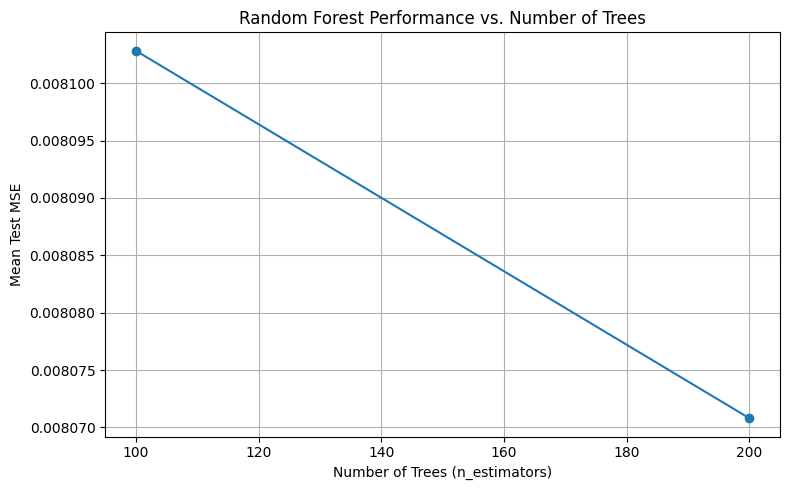

In [12]:
import matplotlib.pyplot as plt

# Extract scores by n_estimators
results = pd.DataFrame(grid_search.cv_results_)
results['n_estimators'] = results['params'].apply(lambda p: p['estimator__n_estimators'])

# Group by n_estimators and average the scores
avg_scores = results.groupby('n_estimators')['mean_test_score'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_scores['n_estimators'], -avg_scores['mean_test_score'], marker='o')  # Negate since scores are negative MSE
plt.title("Random Forest Performance vs. Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Mean Test MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Save to a file
joblib.dump(best_clf, 'best_RF_model2.pkl')
print("Model saved as best_RF_model2.pkl")

Grid Search Progress: 724it [3:57:53, 19.72s/it]

Model saved as best_RF_model2.pkl


In [9]:
# Predict on the test set
y_pred = best_clf.predict(X_test)

# Regression evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRegression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Regression Evaluation Metrics:
Mean Squared Error (MSE): 0.0080
Mean Absolute Error (MAE): 0.0745
R² Score: 0.2157



Classification Evaluation Metrics:
Confusion Matrix:
[[591 255 154  58]
 [290 333 261 174]
 [135 296 358 269]
 [ 42 174 285 557]]
Accuracy: 0.4345
Precision: 0.4345
Recall: 0.4345
F1 Score: 0.4345


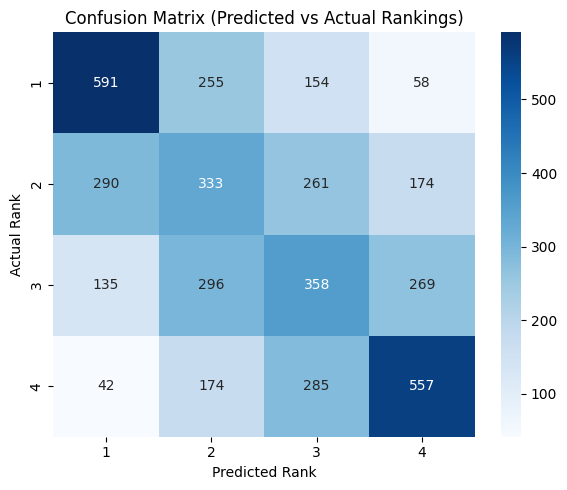

In [10]:
# Function to convert a dictionary of model scores into rankings (1 = best, 4 = worst)
def convert_to_ranking(scores):
    sorted_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return {model: rank + 1 for rank, (model, _) in enumerate(sorted_models)}

# Ensure consistent model order
model_names = list(y.columns)

# Convert actual and predicted scores to rankings per model
actual_ranks = []
predicted_ranks = []

for i in range(len(X_test)):
    actual_scores = dict(zip(model_names, y_test.iloc[i].values))
    predicted_scores = dict(zip(model_names, y_pred[i]))

    actual_ranking = convert_to_ranking(actual_scores)
    predicted_ranking = convert_to_ranking(predicted_scores)

    # Collect rankings per model (ensuring matching order)
    for model in model_names:
        actual_ranks.append(actual_ranking[model])
        predicted_ranks.append(predicted_ranking[model])

# Compute classification metrics
conf_mat = confusion_matrix(actual_ranks, predicted_ranks, labels=[1, 2, 3, 4])
acc_score = accuracy_score(actual_ranks, predicted_ranks)
precision_val = precision_score(actual_ranks, predicted_ranks, average='macro')
recall_val = recall_score(actual_ranks, predicted_ranks, average='macro')
f1_val = f1_score(actual_ranks, predicted_ranks, average='macro')

# Print metrics
print("\nClassification Evaluation Metrics:")
print("Confusion Matrix:")
print(conf_mat)
print(f"Accuracy: {acc_score:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1 Score: {f1_val:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.title("Confusion Matrix (Predicted vs Actual Rankings)")
plt.xlabel("Predicted Rank")
plt.ylabel("Actual Rank")
plt.tight_layout()
plt.show()


Evaluation for Predicting Best Model (Rank 1 Only):
Confusion Matrix:
[[  3  68 132   0]
 [  3 258 134   2]
 [  0  48 319   8]
 [  0   9  63  11]]
Accuracy: 0.5586
Precision: 0.5474
Recall: 0.4120
F1 Score: 0.3814


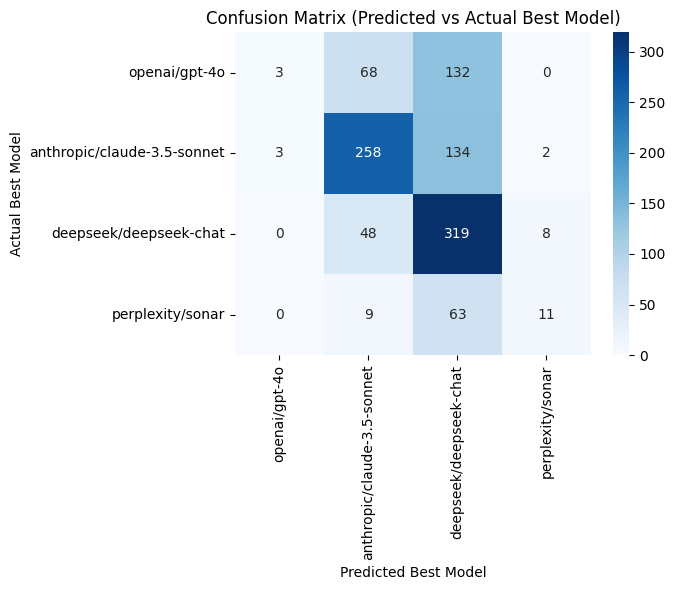

In [11]:
# Function to convert scores to rankings
def convert_to_ranking(scores):
    sorted_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return {model: rank + 1 for rank, (model, _) in enumerate(sorted_models)}

# Consistent model order
model_names = list(y.columns)

# Evaluate only the best-ranked model per prompt
actual_best_models = []
predicted_best_models = []

for i in range(len(X_test)):
    actual_scores = dict(zip(model_names, y_test.iloc[i].values))
    predicted_scores = dict(zip(model_names, y_pred[i]))

    actual_ranking = convert_to_ranking(actual_scores)
    predicted_ranking = convert_to_ranking(predicted_scores)

    actual_best = [model for model, rank in actual_ranking.items() if rank == 1][0]
    predicted_best = [model for model, rank in predicted_ranking.items() if rank == 1][0]

    actual_best_models.append(actual_best)
    predicted_best_models.append(predicted_best)

# Compute classification metrics
acc_score = accuracy_score(actual_best_models, predicted_best_models)
precision_val = precision_score(actual_best_models, predicted_best_models, average='macro')
recall_val = recall_score(actual_best_models, predicted_best_models, average='macro')
f1_val = f1_score(actual_best_models, predicted_best_models, average='macro')
conf_mat = confusion_matrix(actual_best_models, predicted_best_models, labels=model_names)

# Print metrics
print("\nEvaluation for Predicting Best Model (Rank 1 Only):")
print("Confusion Matrix:")
print(conf_mat)
print(f"Accuracy: {acc_score:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1 Score: {f1_val:.4f}")

# Confusion matrix plot
plt.figure(figsize=(7, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_names, yticklabels=model_names)
plt.title("Confusion Matrix (Predicted vs Actual Best Model)")
plt.xlabel("Predicted Best Model")
plt.ylabel("Actual Best Model")
plt.tight_layout()
plt.show()

In [5]:
import joblib
import numpy as np
import pandas as pd

# Load the saved ensemble model
best_clf = joblib.load('best_RF_model2.pkl')

# (Assumes that X_test and y_test are already defined from your previous code)
# For example:
# X_test: numpy array of test set features
# y_test: DataFrame with columns corresponding to each LLM's scores

# Run predictions on the test set
y_pred = best_clf.predict(X_test)

In [6]:
# Function to convert scores into a ranking dictionary.
# Lower rank number indicates a better (higher) score.
def convert_to_ranking(scores):
    # Sort models by their score (highest first)
    sorted_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    # Assign ranks: 1 is best, 2 is second best, etc.
    return {model: rank + 1 for rank, (model, _) in enumerate(sorted_models)}

# Get the model names (assumed to be the same as the columns of y_test)
model_names = list(y_test.columns)

# Initialize a dictionary to store accumulated points per LLM
llm_points = {model: 0 for model in model_names}
total_examples = len(X_test)

In [7]:
# Loop over all test examples
for i in range(total_examples):
    # Get the ground truth scores and the ensemble's predicted scores for the current example
    true_scores = dict(zip(model_names, y_test.iloc[i].values))
    pred_scores = dict(zip(model_names, y_pred[i]))
    
    # Convert scores to rankings based on the ground truth and predicted scores
    true_ranking = convert_to_ranking(true_scores)
    ensemble_ranking = convert_to_ranking(pred_scores)
    
    # Determine the ensemble's best predicted model (rank 1 in the ensemble ranking)
    ensemble_best = [model for model, rank in ensemble_ranking.items() if rank == 1][0]
    
    # Compare the ensemble's prediction to each LLM's ground truth ranking
    for llm in model_names:
        if ensemble_best == llm:
            # Tie: ensemble picked the same model as the LLM
            points = 0.5
        else:
            # If the ensemble's best model is better (i.e. lower rank) than the LLM in ground truth,
            # assign 1 point. Otherwise, assign 0.
            points = 1 if true_ranking[ensemble_best] < true_ranking[llm] else 0
        llm_points[llm] += points

# Compute win rate for each LLM (as a percentage)
win_rates = {llm: (points / total_examples) * 100 for llm, points in llm_points.items()}

In [8]:
# Print the win rates
print("Win Rates for each LLM (comparing ensemble prediction to ground truth):")
for llm, rate in win_rates.items():
    print(f"{llm}: {rate:.2f}%")

Win Rates for each LLM (comparing ensemble prediction to ground truth):
openai/gpt-4o: 72.78%
anthropic/claude-3.5-sonnet: 63.37%
deepseek/deepseek-chat: 62.10%
perplexity/sonar: 86.91%
